In [13]:
from egfr_binder_expression.dataset import get_data
import seaborn as sns


In [10]:


def calc_percentage_charged(sequence):
    charged = set('RKHDE')
    return sum(1 for aa in sequence if aa in charged) / len(sequence)

def calc_percentage_hydrophobic(sequence):
    hydrophobic = set('VILMFYW')
    return sum(1 for aa in sequence if aa in hydrophobic) / len(sequence)



In [20]:
df['nc_adjusted_expression'].value_counts()

nc_adjusted_expression
high      223
none      162
medium     47
low        29
Name: count, dtype: int64

In [14]:
df = get_data()

⠋ Fetching artifact... 

2024-10-12 07:57:57.600 | INFO     | polaris._artifact:_validate_version:66 - The version of Polaris that was used to create the artifact (0.8.7.dev1+g23fd61e.d20240926) is different from the currently installed version of Polaris (0.8.6).
2024-10-12 07:57:57.602 | INFO     | polaris.mixins._checksum:verify_checksum:65 - To verify the checksum, we need to recompute it. This can be slow for large datasets.


✅ SUCCESS: Fetched artifact.
 


/Users/alexandernaka/code/egfr_binder_expression/.venv/lib/python3.11/site-packages/yaspin/core.py:239: UserWarning: color, on_color and attrs are not supported when running in jupyter
  self._color = self._set_color(value) if value else value


In [15]:
df['percentage_charged'] = df['sequence'].apply(calc_percentage_charged)
df['percentage_hydrophobic'] = df['sequence'].apply(calc_percentage_hydrophobic)


In [ ]:
sns.swarmplot(x='nc_adjusted_expression', y='percentage_charged', data=df, order=['none','low', 'medium', 'high'])


/Users/alexandernaka/code/egfr_binder_expression/.venv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 6.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


<Axes: xlabel='nc_adjusted_expression', ylabel='percentage_hydrophobic'>

/Users/alexandernaka/code/egfr_binder_expression/.venv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 9.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


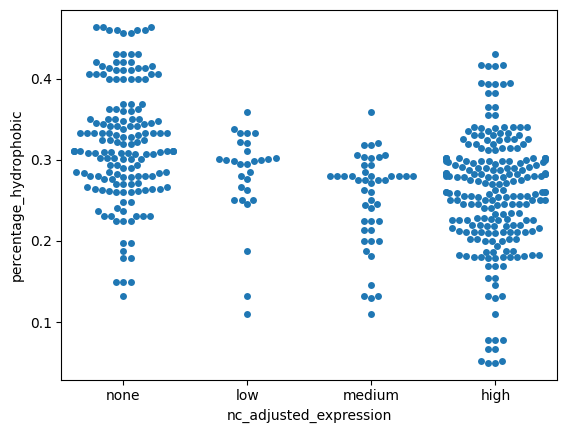

In [23]:
sns.swarmplot(x='nc_adjusted_expression', y='percentage_hydrophobic', data=df, order=['none','low', 'medium', 'high'])


/Users/alexandernaka/code/egfr_binder_expression/.venv/lib/python3.11/site-packages/sklearn/metrics/_scorer.py:610: FutureWarning: The `needs_threshold` and `needs_proba` parameter are deprecated in version 1.4 and will be removed in 1.6. You can either let `response_method` be `None` or set it to `predict` to preserve the same behaviour.
  warnings.warn(
/Users/alexandernaka/code/egfr_binder_expression/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/alexandernaka/code/egfr_binder_expression/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beh

Cross-validation results:
accuracy: 0.465 (+/- 0.226)
f1_macro: 0.265 (+/- 0.146)
precision_macro: 0.306 (+/- 0.119)
recall_macro: 0.318 (+/- 0.096)
roc_auc_ovr: 0.592 (+/- 0.136)

Feature Importance:
                  feature  importance
2      percentage_charged    0.365541
1  percentage_hydrophobic    0.343825
0                  length    0.290634


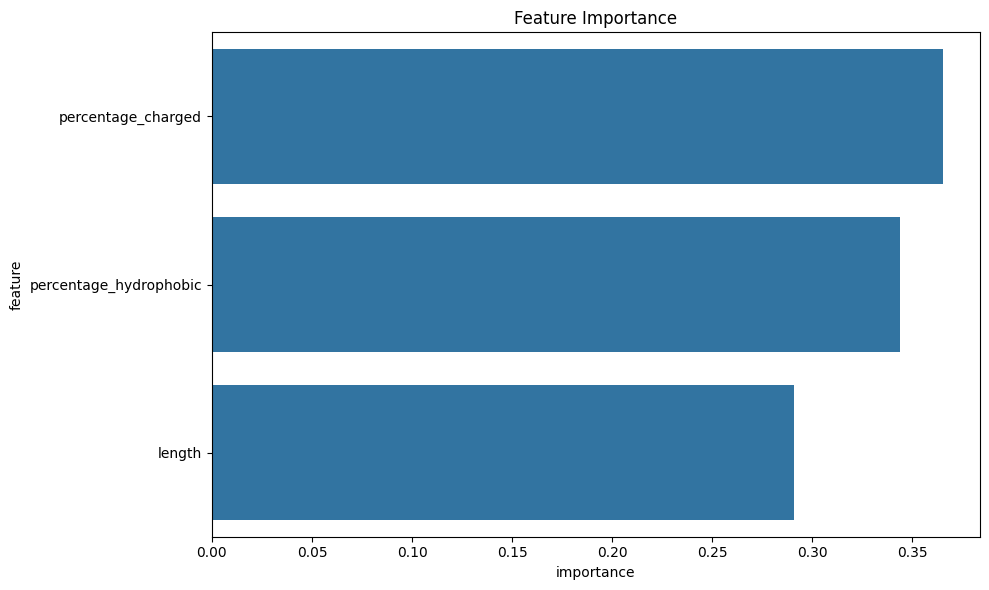


Class balance:
nc_adjusted_expression
high      0.483731
none      0.351410
medium    0.101952
low       0.062907
Name: proportion, dtype: float64


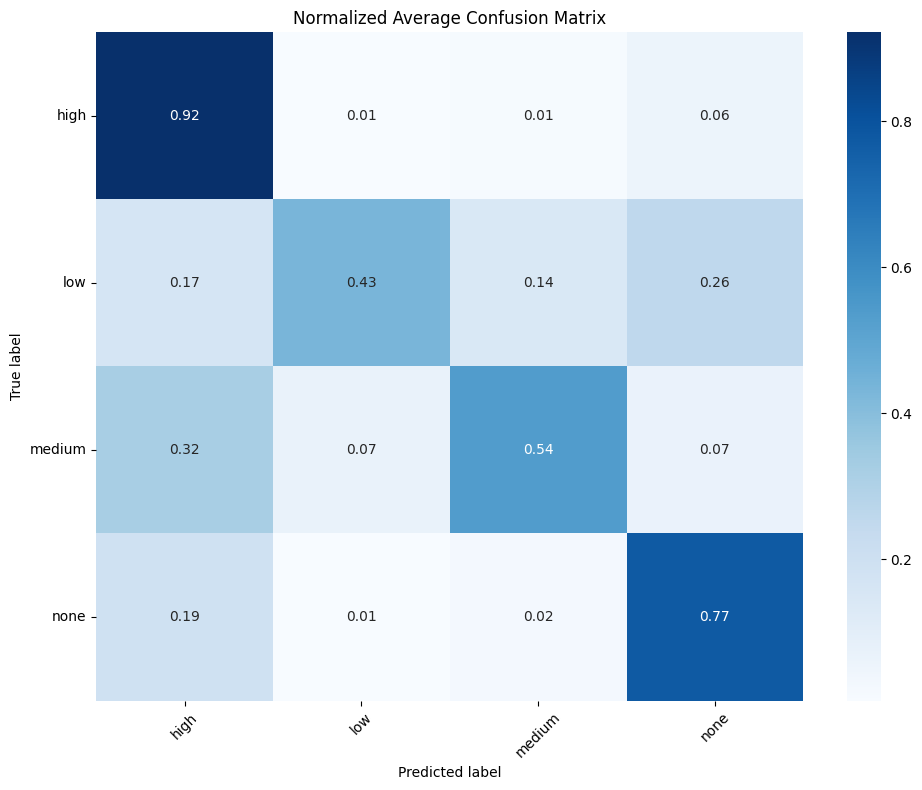

In [34]:
from sklearn.model_selection import GroupShuffleSplit, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare the features and target
X = df[['length', 'percentage_hydrophobic', 'percentage_charged']]
y = df['nc_adjusted_expression']
groups = df['username'].fillna('Unknown')  # Replace None with 'Unknown'

# Encode the target variable
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Define the classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)

# Define the cross-validation strategy
gss = GroupShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

# Define scoring metrics
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'f1_macro': make_scorer(f1_score, average='macro'),
    'precision_macro': make_scorer(precision_score, average='macro'),
    'recall_macro': make_scorer(recall_score, average='macro'),
    'roc_auc_ovr': make_scorer(roc_auc_score, multi_class='ovr', needs_proba=True)
}

# Perform cross-validation
cv_results = cross_validate(clf, X, y_encoded, groups=groups, cv=gss, 
                            scoring=scoring, return_estimator=True, return_train_score=True)

# Print results
print("Cross-validation results:")
for metric in ['accuracy', 'f1_macro', 'precision_macro', 'recall_macro', 'roc_auc_ovr']:
    print(f"{metric}: {cv_results[f'test_{metric}'].mean():.3f} (+/- {cv_results[f'test_{metric}'].std() * 2:.3f})")

# Calculate feature importance
feature_importance = np.mean([estimator.feature_importances_ for estimator in cv_results['estimator']], axis=0)
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("\nFeature Importance:")
print(importance_df)

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=importance_df)
plt.title('Feature Importance')
plt.tight_layout()
plt.show()

# Check class balance
print("\nClass balance:")
print(y.value_counts(normalize=True))

# Compute and plot average confusion matrix
def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion matrix', cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='.2f' if normalize else 'd', cmap=cmap)
    plt.title(title)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.xticks(np.arange(len(classes)) + 0.5, classes, rotation=45)
    plt.yticks(np.arange(len(classes)) + 0.5, classes, rotation=0)
    plt.tight_layout()
    plt.show()

# Compute average confusion matrix
cms = []
for estimator in cv_results['estimator']:
    y_pred = estimator.predict(X)
    cms.append(confusion_matrix(y_encoded, y_pred))
avg_cm = np.mean(cms, axis=0)

# Plot average confusion matrix
plot_confusion_matrix(avg_cm, classes=le.classes_, normalize=True, title='Normalized Average Confusion Matrix')

Cross-validation results:
accuracy: 0.553 (+/- 0.117)
f1: 0.541 (+/- 0.156)
precision: 0.510 (+/- 0.339)
recall: 0.684 (+/- 0.309)
roc_auc: 0.604 (+/- 0.074)

Feature Importance:
                  feature  importance
2      percentage_charged    0.394912
1  percentage_hydrophobic    0.325378
0                  length    0.279711


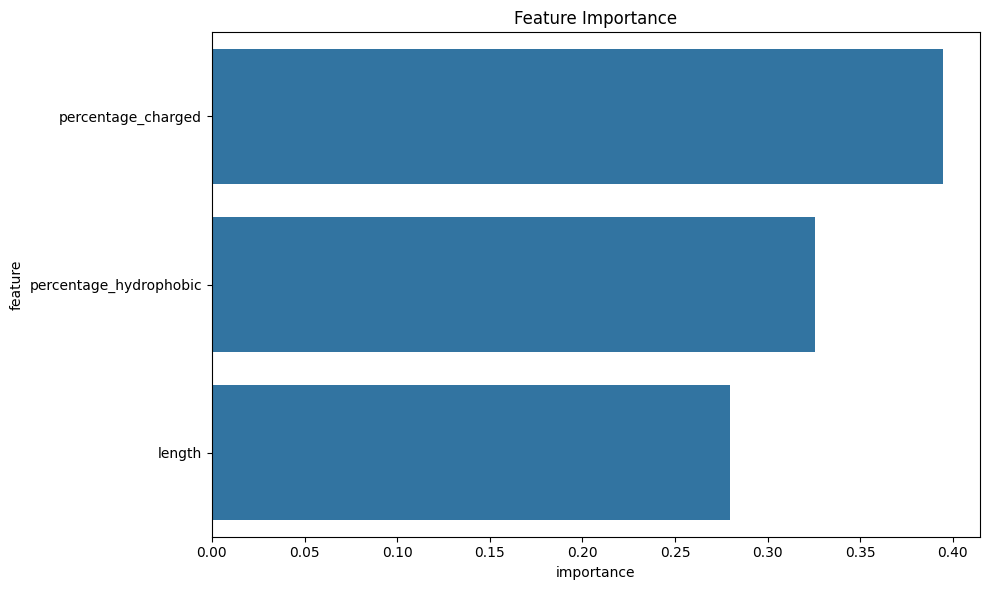


Class balance:
nc_adjusted_expression
0    0.516269
1    0.483731
Name: proportion, dtype: float64


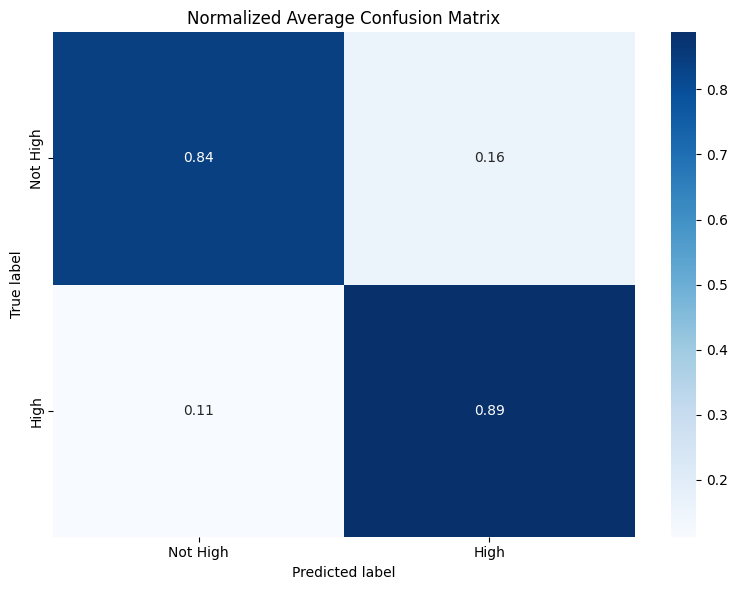

In [36]:
from sklearn.model_selection import GroupShuffleSplit, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare the features and target
X = df[['length', 'percentage_hydrophobic', 'percentage_charged']]
y = (df['nc_adjusted_expression'] == 'high').astype(int)  # 1 if 'high', 0 otherwise
groups = df['username'].fillna('Unknown')  # Replace None with 'Unknown'

# Define the classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)

# Define the cross-validation strategy
gss = GroupShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

# Define scoring metrics
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'f1': make_scorer(f1_score),
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score),
    'roc_auc': make_scorer(roc_auc_score)
}

# Perform cross-validation
cv_results = cross_validate(clf, X, y, groups=groups, cv=gss, 
                            scoring=scoring, return_estimator=True, return_train_score=True)

# Print results
print("Cross-validation results:")
for metric in ['accuracy', 'f1', 'precision', 'recall', 'roc_auc']:
    print(f"{metric}: {cv_results[f'test_{metric}'].mean():.3f} (+/- {cv_results[f'test_{metric}'].std() * 2:.3f})")

# Calculate feature importance
feature_importance = np.mean([estimator.feature_importances_ for estimator in cv_results['estimator']], axis=0)
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("\nFeature Importance:")
print(importance_df)

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=importance_df)
plt.title('Feature Importance')
plt.tight_layout()
plt.show()

# Check class balance
print("\nClass balance:")
print(y.value_counts(normalize=True))

# Compute and plot average confusion matrix
def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion matrix', cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='.2f' if normalize else 'd', cmap=cmap)
    plt.title(title)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.xticks([0.5, 1.5], classes)
    plt.yticks([0.5, 1.5], classes)
    plt.tight_layout()
    plt.show()

# Compute average confusion matrix
cms = []
for estimator in cv_results['estimator']:
    y_pred = estimator.predict(X)
    cms.append(confusion_matrix(y, y_pred))
avg_cm = np.mean(cms, axis=0)

# Plot average confusion matrix
plot_confusion_matrix(avg_cm, classes=['Not High', 'High'], normalize=True, title='Normalized Average Confusion Matrix')

Cross-validation results:
Precision: 0.510 (+/- 0.339)
Recall: 0.684 (+/- 0.309)

Feature Importance:
                  feature  importance
2      percentage_charged    0.394912
1  percentage_hydrophobic    0.325378
0                  length    0.279711


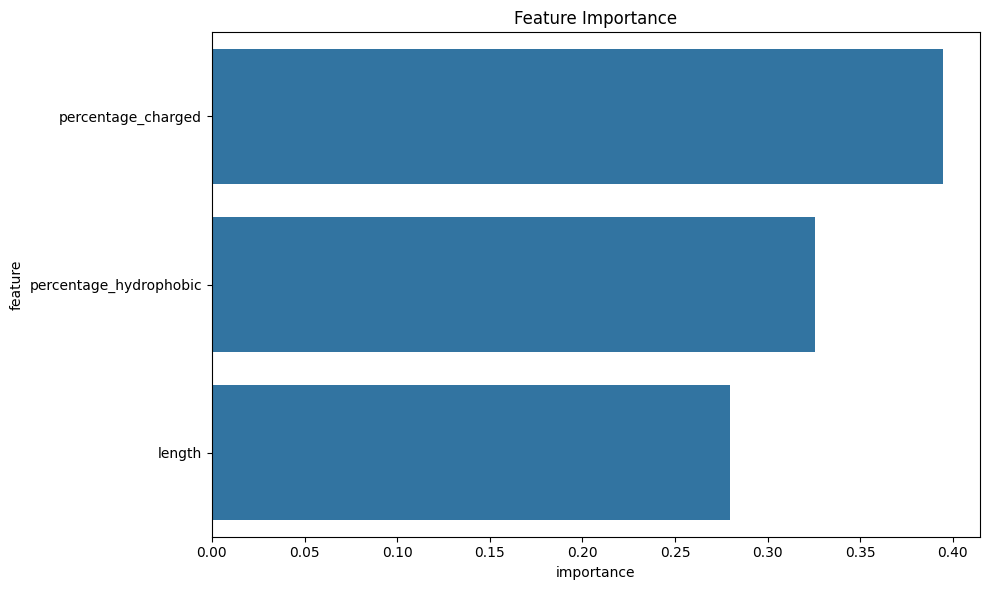


Class balance:
nc_adjusted_expression
0    0.516269
1    0.483731
Name: proportion, dtype: float64


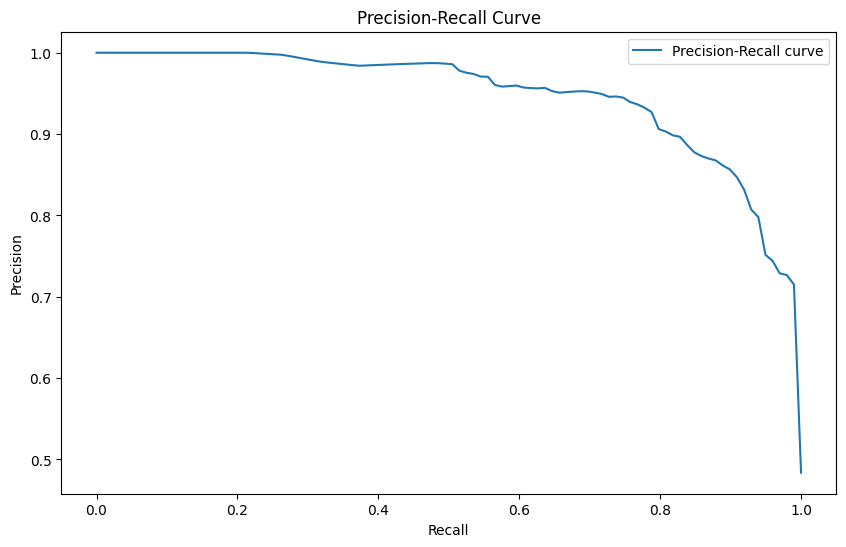


Optimal recall for 0.95 precision: 0.717
Resulting precision: 0.949

High Precision Model Performance:
Precision: 0.952
Recall: 0.680


In [39]:
from sklearn.model_selection import GroupShuffleSplit, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, precision_score, recall_score, precision_recall_curve, auc
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare the features and target
X = df[['length', 'percentage_hydrophobic', 'percentage_charged']]
y = (df['nc_adjusted_expression'] == 'high').astype(int)  # 1 if 'high', 0 otherwise
groups = df['username'].fillna('Unknown')  # Replace None with 'Unknown'

# Define the classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)

# Define the cross-validation strategy
gss = GroupShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

# Perform cross-validation
cv_results = cross_validate(clf, X, y, groups=groups, cv=gss, 
                            scoring=['precision', 'recall'],
                            return_estimator=True, return_train_score=True)

# Print results
print("Cross-validation results:")
print(f"Precision: {cv_results['test_precision'].mean():.3f} (+/- {cv_results['test_precision'].std() * 2:.3f})")
print(f"Recall: {cv_results['test_recall'].mean():.3f} (+/- {cv_results['test_recall'].std() * 2:.3f})")

# Calculate feature importance
feature_importance = np.mean([estimator.feature_importances_ for estimator in cv_results['estimator']], axis=0)
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("\nFeature Importance:")
print(importance_df)

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=importance_df)
plt.title('Feature Importance')
plt.tight_layout()
plt.show()

# Check class balance
print("\nClass balance:")
print(y.value_counts(normalize=True))

# Function to calculate precision and recall for different thresholds
def precision_recall_threshold(estimator, X, y):
    y_scores = estimator.predict_proba(X)[:, 1]
    precisions, recalls, thresholds = precision_recall_curve(y, y_scores)
    return precisions, recalls, thresholds

# Calculate precision and recall for different thresholds
all_precisions = []
all_recalls = []
all_thresholds = []

for estimator in cv_results['estimator']:
    precisions, recalls, thresholds = precision_recall_threshold(estimator, X, y)
    all_precisions.append(precisions)
    all_recalls.append(recalls)
    all_thresholds.append(thresholds)

# Calculate average precision for fixed recall values
fixed_recalls = np.linspace(0, 1, 100)
interpolated_precisions = []

for precisions, recalls in zip(all_precisions, all_recalls):
    interpolated_precisions.append(np.interp(fixed_recalls, recalls[::-1], precisions[::-1]))

mean_precision = np.mean(interpolated_precisions, axis=0)

# Plot precision-recall curve
plt.figure(figsize=(10, 6))
plt.plot(fixed_recalls, mean_precision, label='Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

# Find threshold for high precision (e.g., 0.95)
target_precision = 0.95
threshold_index = np.argmin(np.abs(mean_precision - target_precision))
optimal_recall = fixed_recalls[threshold_index]
optimal_precision = mean_precision[threshold_index]

print(f"\nOptimal recall for {target_precision:.2f} precision: {optimal_recall:.3f}")
print(f"Resulting precision: {optimal_precision:.3f}")

# Function to make predictions with custom threshold
def predict_with_threshold(estimator, X, target_precision):
    y_scores = estimator.predict_proba(X)[:, 1]
    precisions, recalls, thresholds = precision_recall_curve(y, y_scores)
    threshold_index = np.argmin(np.abs(precisions - target_precision))
    optimal_threshold = thresholds[threshold_index]
    return (y_scores >= optimal_threshold).astype(int)

# Evaluate model with optimal threshold
high_precision_results = cross_validate(
    clf, X, y, groups=groups, cv=gss,
    scoring={
        'precision': make_scorer(precision_score),
        'recall': make_scorer(recall_score)
    },
    return_estimator=True
)

high_precision_predictions = [
    predict_with_threshold(estimator, X, target_precision)
    for estimator in high_precision_results['estimator']
]

high_precision_precision = np.mean([
    precision_score(y, pred) for pred in high_precision_predictions
])
high_precision_recall = np.mean([
    recall_score(y, pred) for pred in high_precision_predictions
])

print("\nHigh Precision Model Performance:")
print(f"Precision: {high_precision_precision:.3f}")
print(f"Recall: {high_precision_recall:.3f}")